In [3]:
!pip install -q h2o

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 266.0/266.0 MB 5.4 MB/s eta 0:00:00


In [4]:
import h2o
from h2o.automl import H2OAutoML
import pandas as pd

In [5]:
df= pd.read_csv('/content/heart_failure_clinical_records_dataset.csv')
df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [6]:
h2o.init()

Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
  Java Version: openjdk version "17.0.17" 2025-10-21; OpenJDK Runtime Environment (build 17.0.17+10-Ubuntu-122.04); OpenJDK 64-Bit Server VM (build 17.0.17+10-Ubuntu-122.04, mixed mode, sharing)
  Starting server from /usr/local/lib/python3.12/dist-packages/h2o/backend/bin/h2o.jar
  Ice root: /tmp/tmp2cbw7v6o
  JVM stdout: /tmp/tmp2cbw7v6o/h2o_unknownUser_started_from_python.out
  JVM stderr: /tmp/tmp2cbw7v6o/h2o_unknownUser_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.


H2O_cluster_uptime:,03 secs
H2O_cluster_timezone:,Etc/UTC
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.9
H2O_cluster_version_age:,3 months and 6 days
H2O_cluster_name:,H2O_from_python_unknownUser_pmowpr
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,3.168 Gb
H2O_cluster_total_cores:,2
H2O_cluster_allowed_cores:,2
H2O_cluster_status:,"locked, healthy"


In [7]:
hf = h2o.H2OFrame(df)

Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%


In [8]:
target = "DEATH_EVENT"
features = [col for col in hf.columns if col != target]

In [9]:
hf[target] = hf[target].asfactor()

In [10]:
train, test = hf.split_frame(ratios=[0.8], seed=42)

In [11]:
aml = H2OAutoML(max_models=20, seed=42)
aml.train(x=features, y=target, training_frame=train)

AutoML progress: |█
16:54:36.612: GBM_1_AutoML_1_20260302_165428 [GBM def_5] failed: water.exceptions.H2OModelBuilderIllegalArgumentException: Illegal argument(s) for GBM model: GBM_1_AutoML_1_20260302_165428.  Details: ERRR on field: _min_rows: The dataset size is too small to split for min_rows=100.0: must have at least 200.0 (weighted) rows, but have only 189.0.
ERRR on field: _min_rows: The dataset size is too small to split for min_rows=100.0: must have at least 200.0 (weighted) rows, but have only 189.0.
ERRR on field: _min_rows: The dataset size is too small to split for min_rows=100.0: must have at least 200.0 (weighted) rows, but have only 190.0.
ERRR on field: _min_rows: The dataset size is too small to split for min_rows=100.0: must have at least 200.0 (weighted) rows, but have only 190.0.
ERRR on field: _min_rows: The dataset size is too small to split for min_rows=100.0: must have at least 200.0 (weighted) rows, but have only 190.0.


██████████████████████████████████████

key,value
Stacking strategy,cross_validation
Number of base models (used / total),3/6
# GBM base models (used / total),1/1
# XGBoost base models (used / total),0/1
# DRF base models (used / total),1/2
# GLM base models (used / total),1/1
# DeepLearning base models (used / total),0/1
Metalearner algorithm,GLM
Metalearner fold assignment scheme,Random
Metalearner nfolds,5


In [12]:
aml.leaderboard.head()

model_id,auc,logloss,aucpr,mean_per_class_error,rmse,mse
StackedEnsemble_BestOfFamily_1_AutoML_1_20260302_165428,0.902179,0.370723,0.824685,0.167722,0.34545,0.119336
DRF_1_AutoML_1_20260302_165428,0.900577,0.378544,0.795587,0.161392,0.347701,0.120896
GBM_3_AutoML_1_20260302_165428,0.899856,0.369792,0.846762,0.170886,0.343893,0.118262
StackedEnsemble_AllModels_1_AutoML_1_20260302_165428,0.899776,0.374184,0.820832,0.177215,0.347718,0.120908
GBM_grid_1_AutoML_1_20260302_165428_model_2,0.898173,0.389522,0.812327,0.164557,0.354535,0.125695
GBM_2_AutoML_1_20260302_165428,0.898173,0.385338,0.821861,0.164557,0.353143,0.12471
XGBoost_grid_1_AutoML_1_20260302_165428_model_4,0.89609,0.405087,0.795807,0.161392,0.353576,0.125016
GBM_4_AutoML_1_20260302_165428,0.892004,0.391127,0.825637,0.183544,0.355867,0.126641
XRT_1_AutoML_1_20260302_165428,0.890522,0.399768,0.793526,0.18038,0.356906,0.127382
XGBoost_grid_1_AutoML_1_20260302_165428_model_1,0.887037,0.487374,0.762381,0.186709,0.386191,0.149144


In [13]:
preds = aml.leader.predict(test)
preds.head()

stackedensemble prediction progress: |███████████████████████████████████████████| (done) 100%


predict,p0,p1
1,0.0788485,0.921151
1,0.18387,0.81613
1,0.167628,0.832372
1,0.236376,0.763624
1,0.155121,0.844879
1,0.122014,0.877986
1,0.154532,0.845468
1,0.163134,0.836866
1,0.167369,0.832631
1,0.0891894,0.910811


/usr/local/lib/python3.12/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


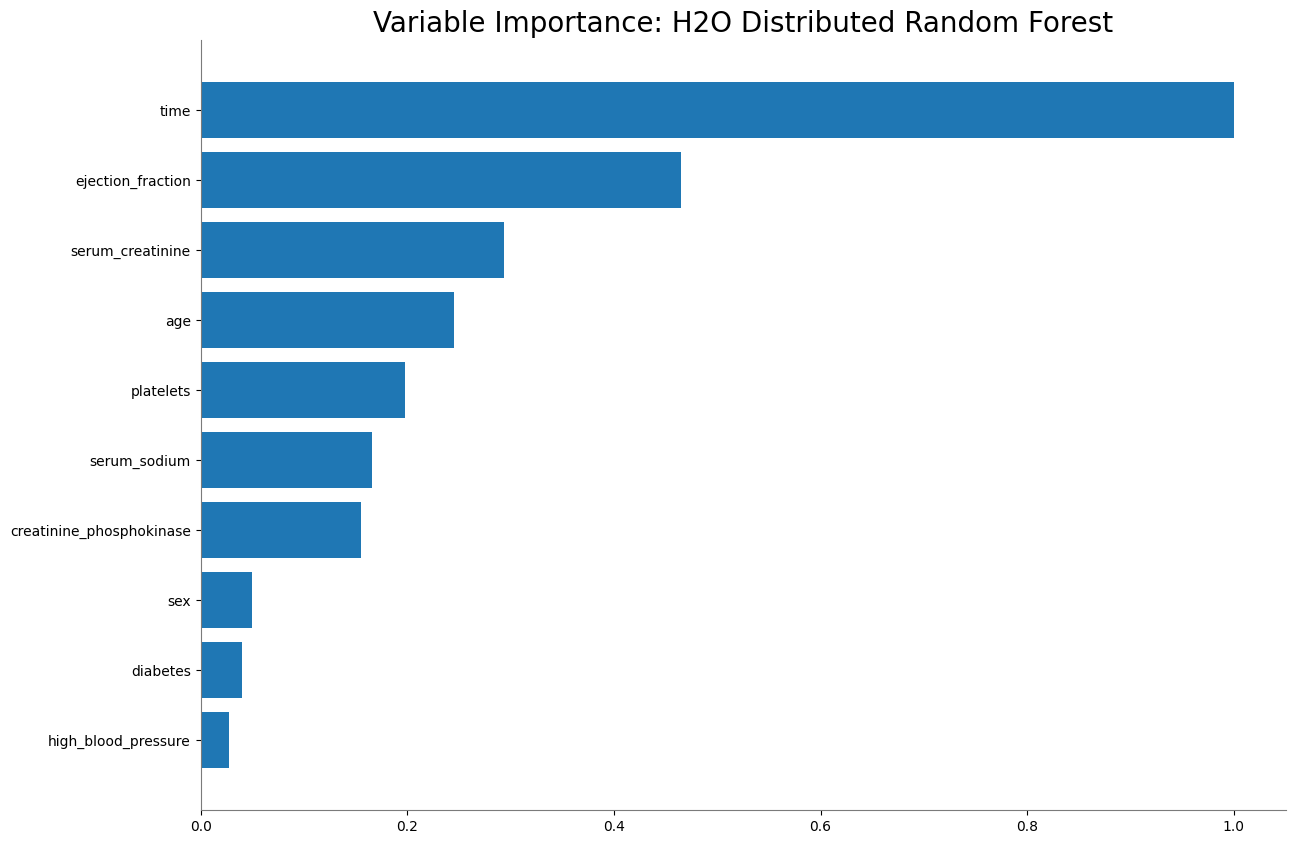

<Figure size 640x480 with 0 Axes>

In [15]:
model_ids = list(aml.leaderboard['model_id'].as_data_frame().iloc[:, 0])
for model_id in model_ids:
    if 'StackedEnsemble' not in model_id:
        non_ensemble_leader = h2o.get_model(model_id)
        break

if non_ensemble_leader:
    non_ensemble_leader.varimp_plot()
else:
    print("No non-StackedEnsemble model found in the leaderboard to plot variable importance.")

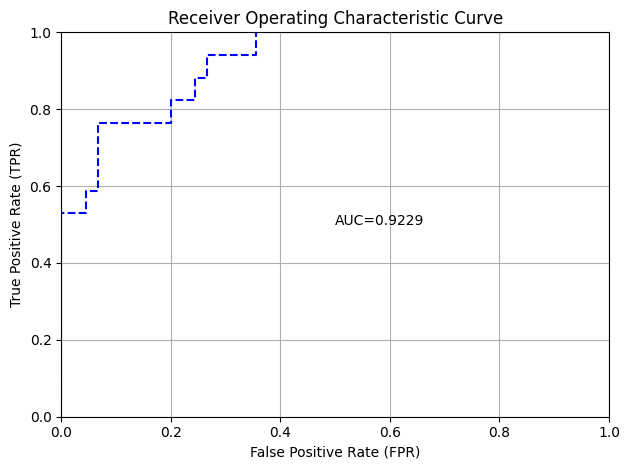

([0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.022222222222222223,
  0.044444444444444446,
  0.044444444444444446,
  0.06666666666666667,
  0.06666666666666667,
  0.06666666666666667,
  0.06666666666666667,
  0.08888888888888889,
  0.1111111111111111,
  0.13333333333333333,
  0.15555555555555556,
  0.17777777777777778,
  0.2,
  0.2,
  0.2222222222222222,
  0.24444444444444444,
  0.24444444444444444,
  0.26666666666666666,
  0.26666666666666666,
  0.28888888888888886,
  0.3111111111111111,
  0.3333333333333333,
  0.35555555555555557,
  0.35555555555555557,
  0.37777777777777777,
  0.4,
  0.4222222222222222,
  0.4444444444444444,
  0.4666666666666667,
  0.4888888888888889,
  0.5111111111111111,
  0.5333333333333333,
  0.5555555555555556,
  0.5777777777777777,
  0.6,
  0.6222222222222222,
  0.6444444444444445,
  0.6666666666666666,
  0.6888888888888889,
  0.7111111111111111,
  0.7333333333333333,
  0.7555555555555555,
  0.7777777777777778,
  0.8,
  0.8222222222222222,


In [16]:
perf = aml.leader.model_performance(test)
perf.plot(type="roc")

In [17]:
perf.confusion_matrix()

,0,1,Error,Rate
0,42.0,3.0,0.0667,(3.0/45.0)
1,4.0,13.0,0.2353,(4.0/17.0)
Total,46.0,16.0,0.1129,(7.0/62.0)
